In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

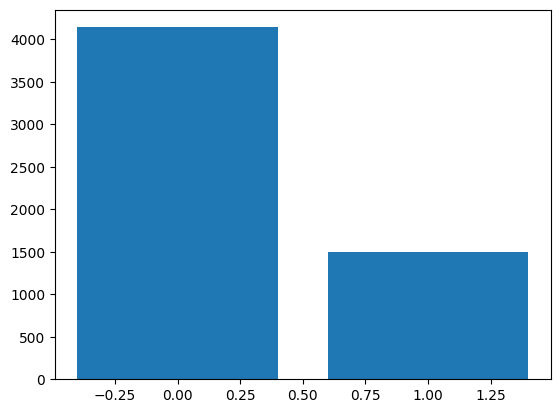

In [28]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= train_df.drop(columns=['SampleID', 'Churn'])
y= train_df['Churn']

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify=y, random_state= seed)

X_test= test_df.drop(columns=['SampleID'])

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()

In [29]:
# Subtask 1

answer1= pd.DataFrame([{
    'id': row['SampleID'],
    'subtaskID': 1,
    'answer': (row['Monthly Charge'] > 70) + (row['Total Extra Data Charges'] > 10)
} for _, row in test_df.iterrows()])

answer1.head()

,id,subtaskID,answer
0,5635,1,0
1,5636,1,1
2,5637,1,0
3,5638,1,1
4,5639,1,0


In [30]:
# Subtask 2

answer2= pd.DataFrame([{
    'id': row['SampleID'],
    'subtaskID': 2,
    'answer': (row['Avg Speed'] < 50)+ (row['Ping Score'] > 80)+ (row['Link Quality Index'] < 30)
} for _, row in test_df.iterrows()])

answer2.head()

,id,subtaskID,answer
0,5635,2,0
1,5636,2,0
2,5637,2,1
3,5638,2,0
4,5639,2,1


In [31]:
# Subtask 3

from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include=['object', 'string']).columns.to_list()

for col in cat_cols:
    X_train[col]= X_train[col].astype(str).fillna('missing')
    X_eval[col]= X_eval[col].astype(str).fillna('missing')
    X_test[col]= X_test[col].astype(str).fillna('missing')

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features=cat_cols,
    auto_class_weights='Balanced',
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose= 200
)

predictions= model.predict(X_test)

answer3= pd.DataFrame([{
    'id': id_,
    'subtaskID': 3,
    'answer': pred
} for id_, pred in zip(test_df['SampleID'], predictions)])

answer3.head()

0:	learn: 0.6245209	test: 0.6240180	best: 0.6240180 (0)	total: 125ms	remaining: 6m 13s
200:	learn: 0.0815104	test: 0.1170050	best: 0.1169172 (199)	total: 3.74s	remaining: 52.1s
400:	learn: 0.0541926	test: 0.1150858	best: 0.1149377 (339)	total: 7.39s	remaining: 47.9s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1149377394
bestIteration = 339

Shrink model to first 340 iterations.


,id,subtaskID,answer
0,5635,3,0
1,5636,3,0
2,5637,3,1
3,5638,3,0
4,5639,3,1


In [32]:
answer= pd.concat([answer1, answer2, answer3])
answer.to_csv("submission.csv", index= False)